In [1]:
import sys
from tqdm import tqdm

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.processor import Processor
from main import init_parser, update_parameters

In [2]:
parser = init_parser()
evaluation_case = 'CV'
# (T2: 12 Apr) Model
sys.argv = ['notebook_cell', '--config', './config/ntu_ablation/ntu60_angle-view.yaml', '-e', '--alignment', 'unaligned']
args = parser.parse_args()
args = update_parameters(parser, args)  # cmd > yaml > default

p = Processor(args)
p.start()

[ 2026-04-28 11:17:53,660 ] Saving folder path: ./workdir/ntu_angle/temp
[ 2026-04-28 11:17:53,660 ] 
[ 2026-04-28 11:17:53,662 ] Saving model name: Trans-GCN_ntu60
[ 2026-04-28 11:17:53,811 ] Using unaligned data.
[ 2026-04-28 11:18:07,162 ] Dataset: ntu60
[ 2026-04-28 11:18:07,164 ] Batch size: train-64, eval-128
[ 2026-04-28 11:18:07,164 ] Data shape (branch, channel, frame, joint, person): [1, 3, 64, 25, 2]
[ 2026-04-28 11:18:07,165 ] Number of action classes: 60
[ 2026-04-28 11:18:07,188 ] Model: Trans-GCN {'use_att': True, 'kernel_size': [3, 2], 'dilations': [2, 3], 'reduct_ratio': 2, 'use_gcn': False, 'so2_arg': {'heads': 8, 'angle_partitions': 6, 'rot_one_axis': False}}
[ 2026-04-28 11:18:08,561 ] Model profile: 0.57G FLOPs and 0.74M Parameters
[ 2026-04-28 11:18:09,500 ] Optimizer: SGD {'lr': 0.1, 'momentum': 0.9, 'nesterov': True, 'weight_decay': 0.0002}
[ 2026-04-28 11:18:09,501 ] LR_Scheduler: step {'max_epoch': 100, 'warm_up': 0, 'step_lr': [80, 90]}
[ 2026-04-28 11:18:09,

100%|██████████| 148/148 [00:55<00:00,  2.65it/s]

[ 2026-04-28 11:19:05,603 ] Top-1 accuracy: 12894/18932(68.11%), MPCA: 68.11%, Top-5 accuracy: 17212/18932(90.91%), Mean loss:1.3208
[ 2026-04-28 11:19:05,604 ] Evaluating time: 55.79s, Speed: 339.54 sequnces/(second*GPU)
[ 2026-04-28 11:19:05,605 ] 
[ 2026-04-28 11:19:05,611 ] Finish evaluating!


In [3]:
def ntu60_label_to_name(label: int) -> str:
    """
    Returns the NTU RGB+D 60 action name for a given label (0-59).

    Args:
        label (int): Action label in [0, 59]

    Returns:
        str: Action class name
    """
    ntu60_classes = [
        "drink water", #0
        "eat meal/snack", #1
        "brushing teeth", #2
        "brushing hair", #3
        "drop", #4
        "pickup", #5
        "throw", #6
        "sitting down", #7
        "standing up (from sitting position)", #8
        "clapping", #9
        "reading", #10
        "writing", #11
        "tear up paper", #12
        "wear jacket", #13
        "take off jacket", #14
        "wear a shoe", #15
        "take off a shoe", #16
        "wear on glasses", #17
        "take off glasses", #18
        "put on a hat/cap", #19
        "take off a hat/cap", #20
        "cheer up", #21
        "hand waving", #22
        "kicking something", #23
        "reach into pocket", #24
        "hopping (one foot jumping)", #25
        "jump up", #26
        "make a phone call/answer phone", #27
        "playing with phone/tablet", #28
        "typing on a keyboard", #29
        "pointing to something with finger", #30
        "taking a selfie", #31
        "check time (from watch)", #32
        "rub two hands together", #33
        "nod head/bow", #34
        "shake head", #35
        "wipe face", #36
        "salute", #37
        "put palms together", #38
        "cross hands in front (say stop)", #39
        "sneeze/cough", #40
        "staggering", #41
        "falling", #42
        "touch head (headache)", #43
        "touch chest (stomachache/heart pain)", #44
        "touch back (backache)", #45
        "touch neck (neckache)", #46
        "nausea or vomiting condition", #47
        "use a fan (with hand or paper)/feeling warm", #48
        "punching/slapping other person", #49
        "kicking other person", #50
        "pushing other person", #51
        "pat on back of other person", #52
        "point finger at the other person", #53
        "hugging other person", #54
        "giving something to other person", #55
        "touch other person's pocket", #56
        "handshaking", #57
        "walking towards each other", #58
        "walking apart from each other" #59
    ]

    if not (0 <= label < 60):
        raise ValueError("Label must be in the range [0, 59].")

    return ntu60_classes[label]


In [4]:

def get_correct_samples(p, class_idx, count=1, split='train', device='cuda', debug=False):
    """
    Returns N correctly classified samples of a given class.
    
    Output:
        xs: list of tensors
        ys: list of labels
    """
    model = p.model

    model.eval()
    xs, ys = ([], []) if not debug else (set(),set())

    loader = p.train_loader if split == 'train' else p.eval_loader

    with torch.no_grad():
        for x_batch, y_batch in tqdm(loader, dynamic_ncols=True):

            x_batch = x_batch.float().to(device)
            y_batch = y_batch.to(device)

            # forward pass
            outputs,_ = model(x_batch)
            preds = outputs.argmax(dim=1)

            # loop through batch
            for i in range(len(y_batch)):
                y_true = y_batch[i].item()
                y_pred = preds[i].item()

                if not debug:
                    if y_true == class_idx and y_pred == class_idx:
                        xs.append(x_batch[i].cpu())
                        ys.append(y_true)

                        if len(xs) == count:
                            return xs, ys
                else:
                    if y_true == y_pred:
                        ys.add(y_true)
                    

    return (xs, ys) if not debug else ys  # may be < count if not enough found

In [ ]:
def make_z1f_hook(axis='y', storage_dict=None, name=None):
    def hook(module, input, output):
        x = input[0]  # this is the correctly propagated feature

        NM, T, V, C = x.shape

        sigma = module.sigma_k[axis](
            x.reshape(NM, T, -1).unsqueeze(2)
        ).squeeze(-2)  # (NM, T, n)

        z1_f = torch.sigmoid(sigma)

        storage_dict[name] = z1_f.detach().cpu()

    return hook

In [ ]:
def get_hook(model, storage, input_branch=False, lay=0, head=0, axis='y'):
    """x_sample must match expected shape: (N*M, T, V, C)"""

    # unwrap DataParallel if needed
    net = model.module if isinstance(model, torch.nn.DataParallel) else model

    if input_branch:
        if lay == 0:
            target_layer = net.input_branches[0].layers[lay].scn.gcn
        else:
            target_layer = net.input_branches[0].layers[lay].scn.gcn[head]
    else:
        target_layer = net.main_stream[lay].scn.gcn[head]

    handle = target_layer.register_forward_hook(
        make_z1f_hook(axis=axis, storage_dict=storage, name=f'layer{lay}_head{head}')
    )

    return handle, storage

In [7]:
def plot_z1f_heatmap(z1_f, sample_idx=0, actor=0):
    """
    z1_f: (NM, T, n)
    """
    NM, T, n = z1_f.shape
    z1_f = z1_f.view(-1,2,T,n)

    data = z1_f[sample_idx, actor]  # (T, n)

    plt.figure(figsize=(6, 4))
    plt.imshow(data, aspect='auto')

    plt.title("z1_f heatmap")
    plt.xlabel("Partition index (n)")
    plt.ylabel("Time (T)")

    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [8]:
# debug
# y = get_correct_samples(p, class_idx=None, split='test', debug=True)
# print(f'Correctly classified:\n{y}')

In [9]:
class_idx = 54 # 7: sitting, 8: standing
count = 4
split = 'test'

x, y = get_correct_samples(p, class_idx, count=count, split=split)

class_name = ntu60_label_to_name(class_idx) # class name

print(f"class name is {class_name}.")

  2%|▏         | 3/148 [00:01<01:08,  2.12it/s]

class name is hugging other person.


In [10]:
x_sample = x[0].unsqueeze(0)

model = p.model

layer = 0
head = 0
input_branch = False

storage = {}
handle, storage = get_hook(model, storage, input_branch=input_branch, lay=layer, head=head, axis='y')

model.eval()

with torch.no_grad():
    _ = model(x_sample)  # full forward pass

z1_f = storage[f'layer{layer}_head{head}']  # (NM, T, n)

handle.remove()  # clean up

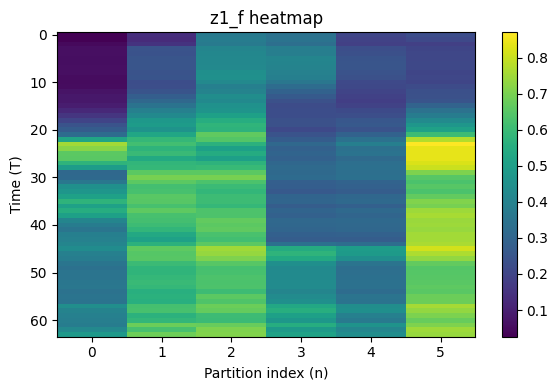

In [11]:
plot_z1f_heatmap(z1_f, actor=0) # z-axis, actor=0

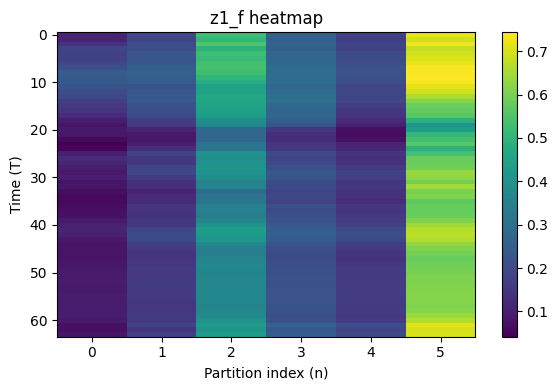

In [12]:
plot_z1f_heatmap(z1_f, actor=1) # z-axis, actor=1

In [ ]:
plot_z1f_heatmap(z1_f) # y-axis, actor=0

In [ ]:
plot_z1f_heatmap(z1_f) # y-axis, actor=1

In [ ]:
plot_z1f_heatmap(z1_f) # x-axis, actor=0

In [ ]:
plot_z1f_heatmap(z1_f) # x-axis, actor=1